# Jonglage - Mustererkennung 2025

Wer sind wir, was machen wir in welchem modul

wofür die jonglage was soll erkannt werden

wie sind wir vorgegangen

verweis auf unser repo mit dem code um die daten aus den videos zu bekommen

### Aufsetzen des Jupiter-Notebooks

In [54]:
import os
import ast
import numpy as np
import pandas as pd
import sklearn.metrics
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Einstellungen für das Anzeigen von Ergebnissen
plt.rcParams["pgf.texsystem"] = "pdflatex"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14.0
plt.rcParams["text.usetex"] = True
plt.rcParams["savefig.bbox"] = "tight"

## Laden und bearbeiten des DataFrames

In [55]:
# DataFrame laden
cwd = os.getcwd()

path_data = cwd + "/test.csv"
df = pd.read_csv(path_data)

# Konvertieren der Strings in jeweilige Datenstruktur
for column in df.columns[1:]:
    df[column] = df[column].apply(ast.literal_eval)

In [56]:
# Extrahieren der Klasse aus dem Videonamen
def extract_classification(name: str):
    if name.endswith("0.mp4"):
        return 0
    return 1

df["classification"] = df["video"].apply(extract_classification)

# Kürzen auf dieselbe Länge
# Bestimmen der benötigten minimalen Frame anzahl (ab 70 Frames)
min_frames = 1000
for x in df["ball_a"]:
    y = len(x)
    if min_frames > y >= 70:
        min_frames = y

print(f"Number of Frames: {min_frames}")


def trim_pairs(entry, frame_count):
    if not isinstance(entry, list):
        return entry

    Z = len(entry) - frame_count
    z = Z // 2
    if Z % 2 != 0:
        return entry[z + 1:len(entry) - z]
    else:
        return entry[z:len(entry) - z]

df = df.map(lambda x: trim_pairs(x, min_frames))
mask = df['ball_a'].apply(lambda x: len(x) >= min_frames if isinstance(x, list) else False)
df = df[mask].reset_index(drop=True)

Number of Frames: 72


In [59]:
# Anpassen des Verhältnisses von stabilen zu nicht stabilen Würfen
num_ones = df['classification'].value_counts().get(1, 0)

zeros = df[df['classification'] == 0]
ones = df[df['classification'] == 1]

sample_zeros = zeros.sample(n=num_ones, random_state=42)

df = pd.concat([sample_zeros, ones])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.shape

(18, 11)

## Klassifikation

- welcher Klassifikator
- warum wie klassifizieren
- nach was klassifizieren

oder so

### Alle Merkmale

In [60]:
# Merkmale auswählen
X = np.array(df[['ball_a','ball_b','ball_c','hand_left','hand_right','elbow_left','elbow_right','shoulder_left','shoulder_right']].apply(lambda x: np.array(x.tolist()).flatten(), axis=1).tolist())
y = df['classification'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# Random Forest
r_f_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

r_f_classifier.fit(X_train, y_train)

y_pred = r_f_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [ ]:
# Naive Bayes
g_classifier = GaussianNB()

g_classifier.fit(X_train, y_train)

y_pred = g_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



In [63]:
# kNN
k = 3
knn_classifier = KNeighborsClassifier(n_neighbors=k)

knn_classifier.fit(X_train, y_train)

y_pred = knn_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.25
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



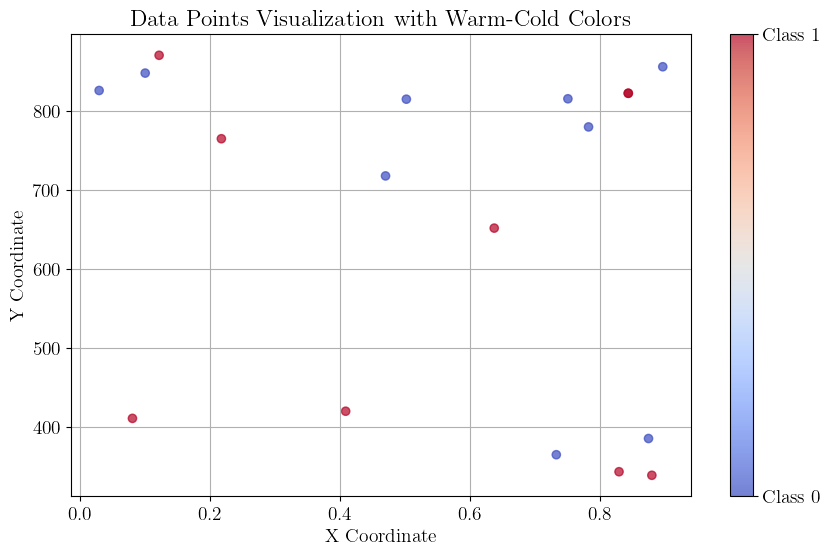

In [65]:
# Visualisierung
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Class 0', 'Class 1'])

plt.title('Data Points Visualization with Warm-Cold Colors')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()